In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

df = pd.read_csv("data/StudentPerformanceFactors.csv")


print(type(df))
print(df.shape)
df.dtypes

<class 'pandas.DataFrame'>
(6607, 20)


Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

## Analyse exploratoire (EDA)

In [3]:
df.info()
df.head()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
colonnes_categorielles = df.select_dtypes(include=["string"]).columns
for col in colonnes_categorielles:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

# print(colonnes_categorielles)


--- Parental_Involvement ---
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

--- Access_to_Resources ---
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

--- Extracurricular_Activities ---
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

--- Motivation_Level ---
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

--- Internet_Access ---
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

--- Family_Income ---
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

--- Teacher_Quality ---
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

--- School_Type ---
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

--- Peer_Influence ---
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

--- Learning

In [ ]:
print(df.isnull().sum())
print("Nombre de doublons :", df.duplicated().sum())

### Distributions

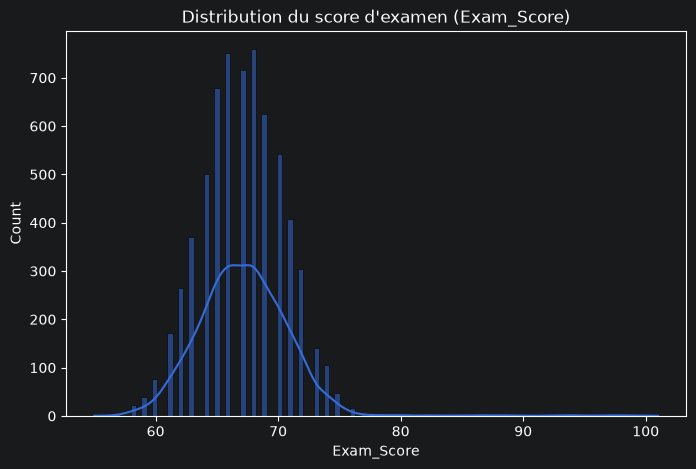

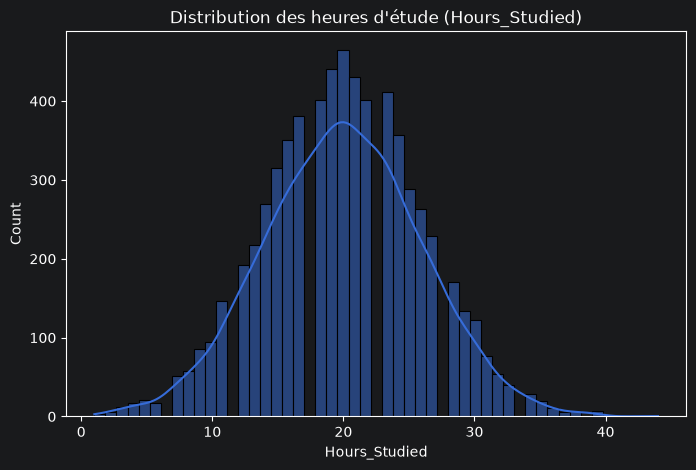

In [5]:
# Histogramme de la variable cible Exam_Score
plt.figure(figsize=(8, 5))
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribution du score d'examen (Exam_Score)")
plt.xlabel("Exam_Score")
plt.show()

# Histogramme de Hours_Studied
plt.figure(figsize=(8, 5))
sns.histplot(df["Hours_Studied"], kde=True)
plt.title("Distribution des heures d'étude (Hours_Studied)")
plt.xlabel("Hours_Studied")
plt.show()

### Matrice de corrélation (avant encodage)

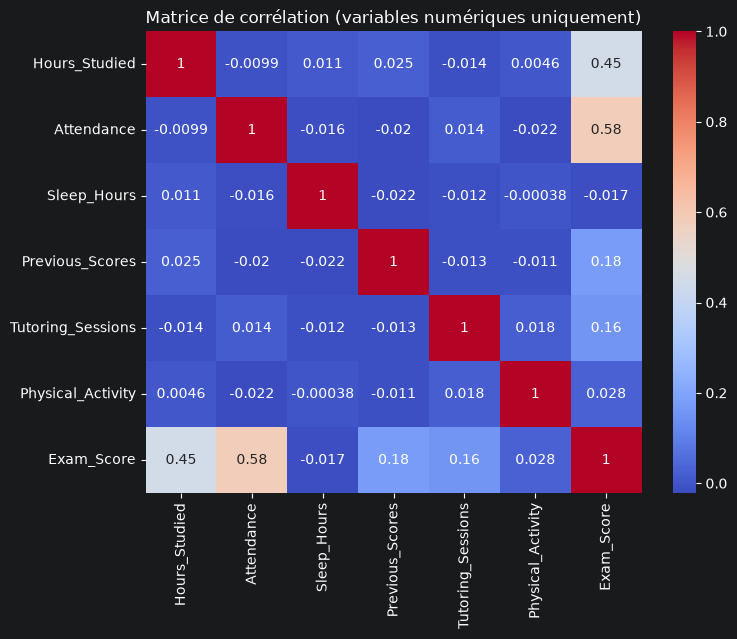

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation (variables numériques uniquement)")
plt.show()

## Prétraitement

In [7]:
colonnes_a_imputer = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

imputer = SimpleImputer(strategy="most_frequent")
df[colonnes_a_imputer] = imputer.fit_transform(df[colonnes_a_imputer])

print(df[colonnes_a_imputer].isnull().sum())

Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


### Suppression des doublons

In [8]:
df.drop_duplicates(inplace=True)
print("Nouvelle taille après suppression des doublons :", df.shape)

Nouvelle taille après suppression des doublons : (6607, 20)


### Valeurs aberrantes (outliers)

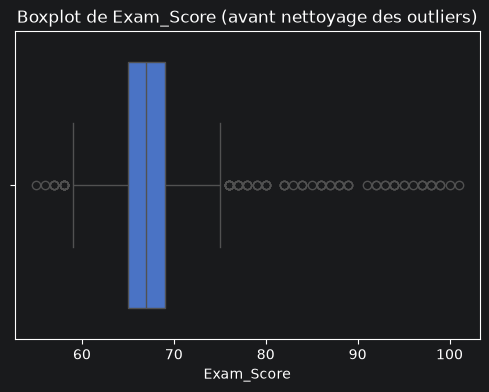

Bornes IQR : [59.00 ; 75.00]
Nombre de lignes avec |z-score| > 3 : 52
Taille après suppression des outliers : (6503, 20)


In [9]:
# a) Visualisation avec un boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Exam_Score"])
plt.title("Boxplot de Exam_Score (avant nettoyage des outliers)")
plt.show()

# b) Méthode IQR (Interquartile Range)
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR
print(f"Bornes IQR : [{borne_basse:.2f} ; {borne_haute:.2f}]")

# c) Vérification avec le z-score
z_scores = (df["Exam_Score"] - df["Exam_Score"].mean()) / df["Exam_Score"].std()
print("Nombre de lignes avec |z-score| > 3 :", (z_scores.abs() > 3).sum())

# d) Suppression selon les bornes IQR
df = df[(df["Exam_Score"] >= borne_basse) & (df["Exam_Score"] <= borne_haute)]
print("Taille après suppression des outliers :", df.shape)

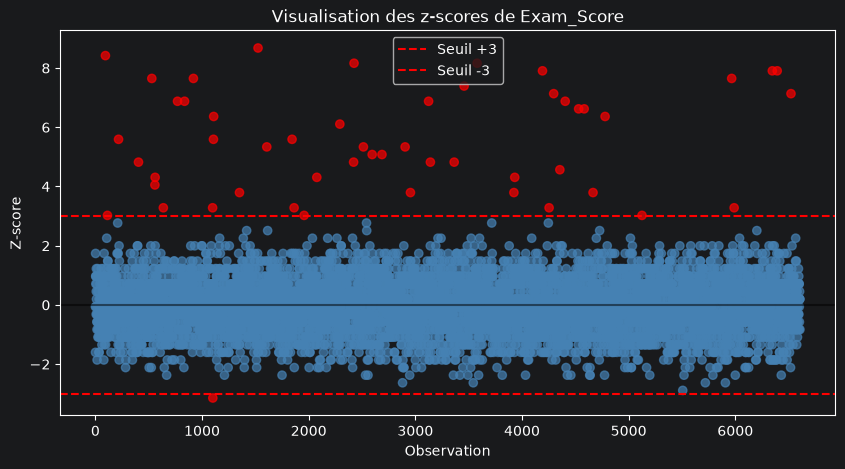

In [10]:
# --- Visualisation des z-scores ---

plt.figure(figsize=(10, 5))

outliers_z = z_scores.abs() > 3

couleurs = np.where(outliers_z, "red", "steelblue")

plt.scatter(range(len(z_scores)),
    z_scores,
    c=couleurs,
    alpha=0.7
)

plt.axhline(y=3, color="red", linestyle="--", label="Seuil +3")
plt.axhline(y=-3, color="red", linestyle="--", label="Seuil -3")

plt.axhline(y=0, color="black", linestyle="-", alpha=0.5)

plt.title("Visualisation des z-scores de Exam_Score")
plt.xlabel("Observation")
plt.ylabel("Z-score")

plt.legend()
plt.show()

### One-hot encoding des variables NOMINALES

In [11]:
colonnes_nominales = [
    "Gender",
    "School_Type",
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
    "Peer_Influence",
]
df = pd.get_dummies(df, columns=colonnes_nominales)

### Encodage ORDINAL des variables ordinales

In [12]:
mapping_low_medium_high = {"Low": 0, "Medium": 1, "High": 2}
mapping_education = {"High School": 0, "College": 1, "Postgraduate": 2}
mapping_distance = {"Near": 0, "Moderate": 1, "Far": 2}

colonnes_ordinales_std = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
]
for col in colonnes_ordinales_std:
    df[col] = df[col].map(mapping_low_medium_high)

df["Parental_Education_Level"] = df["Parental_Education_Level"].map(mapping_education)
df["Distance_from_Home"] = df["Distance_from_Home"].map(mapping_distance)

print(df.dtypes)

Hours_Studied                     int64
Attendance                        int64
Parental_Involvement              int64
Access_to_Resources               int64
Sleep_Hours                       int64
Previous_Scores                   int64
Motivation_Level                  int64
Tutoring_Sessions                 int64
Family_Income                     int64
Teacher_Quality                   int64
Physical_Activity                 int64
Parental_Education_Level          int64
Distance_from_Home                int64
Exam_Score                        int64
Gender_Female                      bool
Gender_Male                        bool
School_Type_Private                bool
School_Type_Public                 bool
Extracurricular_Activities_No      bool
Extracurricular_Activities_Yes     bool
Internet_Access_No                 bool
Internet_Access_Yes                bool
Learning_Disabilities_No           bool
Learning_Disabilities_Yes          bool
Peer_Influence_Negative            bool


In [17]:
df.to_csv(
    "data/StudentPerformanceFactors_cleaned.csv",
    index=False
)
print("Dataset nettoyé sauvegardé avec succès.")

Dataset nettoyé sauvegardé avec succès.


### Séparation X (features) / y (cible)

In [18]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

colonnes_attendues = list(X.columns)
print("Nombre de colonnes finales :", len(colonnes_attendues))

Nombre de colonnes finales : 26


### Découpage train / test (80% / 20%)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Taille train :", X_train.shape, " | Taille test :", X_test.shape)

Taille train : (5202, 26)  | Taille test : (1301, 26)


### StandardScaler sur les variables numériques uniquement

In [20]:
colonnes_numeriques = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
]

preprocesseur = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), colonnes_numeriques)],
    remainder="passthrough",
)

## Entraînement des modèles

In [21]:
modeles = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    # "XGBRegressor": XGBRegressor(random_state=42),
    "SVR": SVR(),
}

resultats_defaut = {}

for nom, modele in modeles.items():
    pipeline = Pipeline(steps=[
        ("preprocesseur", preprocesseur),
        ("modele", modele),
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultats_defaut[nom] = {"RMSE": rmse, "MAE": mae, "R2": r2, "pipeline": pipeline}
    print(f"{nom:25s} | RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f}")

LinearRegression          | RMSE=0.327 | MAE=0.272 | R2=0.990
RandomForestRegressor     | RMSE=1.066 | MAE=0.844 | R2=0.891
SVR                       | RMSE=0.459 | MAE=0.358 | R2=0.980


### Tableau récapitulatif des résultats "par défaut"

In [24]:
df_resultats_defaut = pd.DataFrame({
    nom: {"RMSE": v["RMSE"], "MAE": v["MAE"], "R2": v["R2"]}
    for nom, v in resultats_defaut.items()
}).T
print(df_resultats_defaut)

                           RMSE       MAE        R2
LinearRegression       0.327058  0.271589  0.989723
RandomForestRegressor  1.065924  0.843697  0.890835
SVR                    0.459213  0.358146  0.979739


### Grilles d'hyperparamètres à tester pour chaque modèle.

In [25]:
grilles = {
    "LinearRegression": {
        "modele__fit_intercept": [True, False],
        "modele__positive": [True, False],
    },
    "RandomForestRegressor": {
        "modele__n_estimators": [100, 200, 300],
        "modele__max_depth": [None, 5, 10, 20],
        "modele__min_samples_split": [2, 5, 10],
    },
    # "XGBRegressor": {
    #     "modele__n_estimators": [100, 200, 300],
    #     "modele__learning_rate": [0.01, 0.05, 0.1],
    #     "modele__max_depth": [3, 5, 7],
    #     "modele__subsample": [0.7, 0.85, 1.0],
    # },
    "SVR": {
        "modele__C": [0.1, 1, 10],
        "modele__kernel": ["linear", "rbf"],
        "modele__epsilon": [0.01, 0.1, 0.5],
    },
}

meilleurs_pipelines = {}
resultats_tuning = {}

for nom, modele in modeles.items():
    pipeline = Pipeline(steps=[
        ("preprocesseur", preprocesseur),
        ("modele", modele),
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=grilles[nom],
        cv=3,
        scoring="r2",
        n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)

    meilleur_pipeline = grid_search.best_estimator_
    meilleurs_pipelines[nom] = meilleur_pipeline

    y_pred = meilleur_pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultats_tuning[nom] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{nom:25s} | meilleurs params : {grid_search.best_params_}")
    print(f"{'':25s} | RMSE={rmse:.3f} | MAE={mae:.3f} | R2={r2:.3f}\n")

LinearRegression          | meilleurs params : {'modele__fit_intercept': True, 'modele__positive': False}
                          | RMSE=0.327 | MAE=0.272 | R2=0.990

RandomForestRegressor     | meilleurs params : {'modele__max_depth': None, 'modele__min_samples_split': 2, 'modele__n_estimators': 300}
                          | RMSE=1.059 | MAE=0.840 | R2=0.892

SVR                       | meilleurs params : {'modele__C': 1, 'modele__epsilon': 0.5, 'modele__kernel': 'linear'}
                          | RMSE=0.326 | MAE=0.271 | R2=0.990



### Comparaison avant / après tuning

In [26]:
df_resultats_tuning = pd.DataFrame(resultats_tuning).T
print("=== AVANT tuning ===")
print(df_resultats_defaut)
print("\n=== APRÈS tuning ===")
print(df_resultats_tuning)

=== AVANT tuning ===
                           RMSE       MAE        R2
LinearRegression       0.327058  0.271589  0.989723
RandomForestRegressor  1.065924  0.843697  0.890835
SVR                    0.459213  0.358146  0.979739

=== APRÈS tuning ===
                           RMSE       MAE        R2
LinearRegression       0.327058  0.271589  0.989723
RandomForestRegressor  1.058669  0.840279  0.892316
SVR                    0.326414  0.270939  0.989763


## Évaluation et comparaison des modèles

### Scatter plots : prédictions vs valeurs réelles

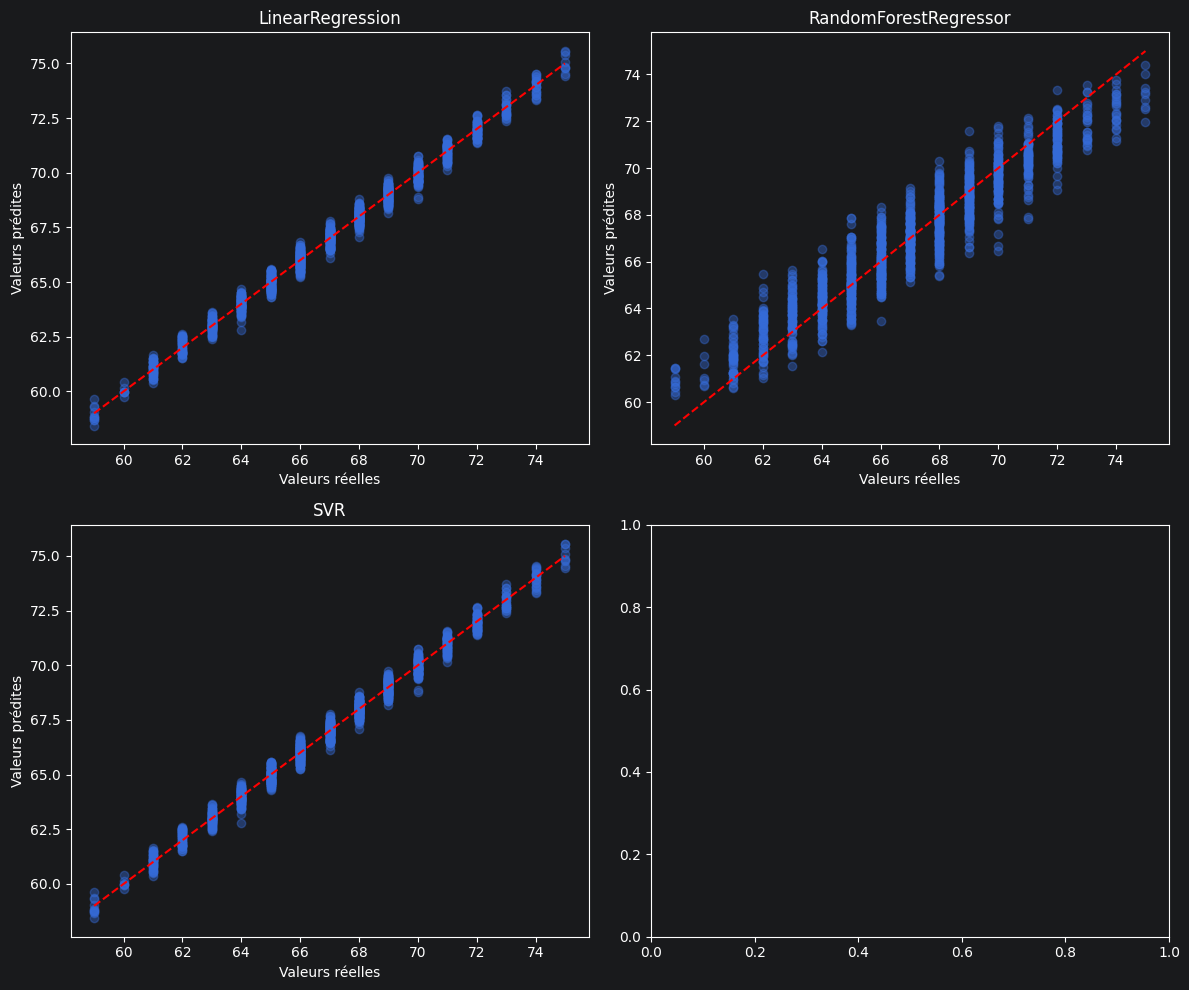

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (nom, pipeline) in enumerate(meilleurs_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    axes[i].scatter(y_test, y_pred, alpha=0.4)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[i].set_title(nom)
    axes[i].set_xlabel("Valeurs réelles")
    axes[i].set_ylabel("Valeurs prédites")

plt.tight_layout()
plt.show()

## Distribution des résidus (erreur = réel - prédit)

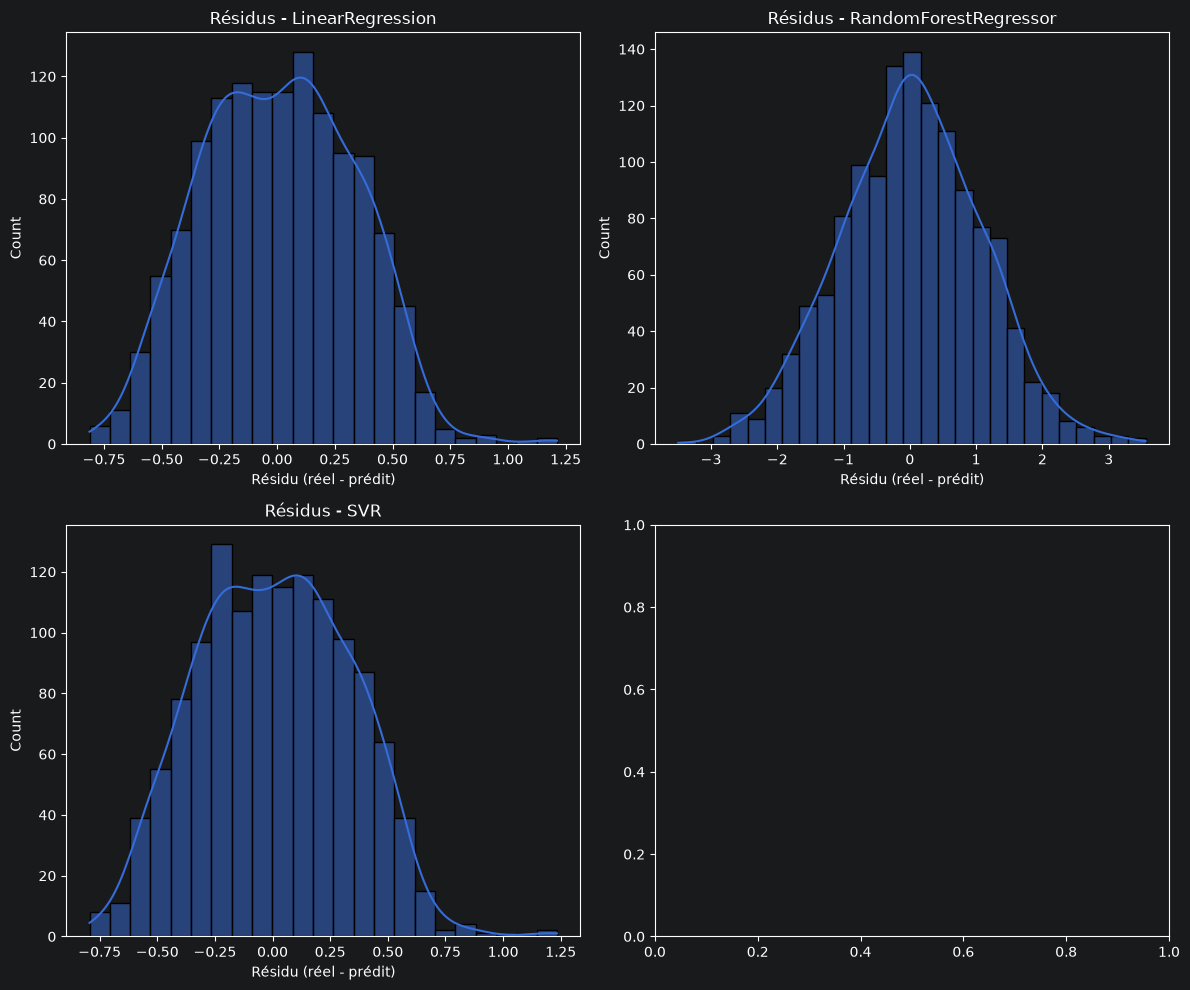

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

residus_par_modele = {}
for i, (nom, pipeline) in enumerate(meilleurs_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    residus = y_test - y_pred
    residus_par_modele[nom] = residus
    sns.histplot(residus, kde=True, ax=axes[i])
    axes[i].set_title(f"Résidus - {nom}")
    axes[i].set_xlabel("Résidu (réel - prédit)")

plt.tight_layout()
plt.show()

### Tableau récapitulatif final

In [28]:
print(df_resultats_tuning)

                           RMSE       MAE        R2
LinearRegression       0.327058  0.271589  0.989723
RandomForestRegressor  1.058669  0.840279  0.892316
SVR                    0.326414  0.270939  0.989763


## Robustesse : écart-type des résidus + écart-type du R² en CV

In [29]:
from sklearn.model_selection import cross_val_score

robustesse = {}
for nom, pipeline in meilleurs_pipelines.items():
    ecart_type_residus = residus_par_modele[nom].std()

    scores_cv = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")

    robustesse[nom] = {
        "Ecart_type_residus": ecart_type_residus,
        "Ecart_type_R2_CV": scores_cv.std(),
        "Moyenne_R2_CV": scores_cv.mean(),
    }

df_robustesse = pd.DataFrame(robustesse).T
print(df_robustesse)

                       Ecart_type_residus  Ecart_type_R2_CV  Moyenne_R2_CV
LinearRegression                 0.327127          0.000404       0.989807
RandomForestRegressor            1.058899          0.006033       0.887166
SVR                              0.326454          0.000396       0.989805


## Choix du modèle final

In [ ]:
NOM_MODELE_FINAL = "SVR"

pipeline_final = meilleurs_pipelines[NOM_MODELE_FINAL]
print(f"Modèle final retenu : {NOM_MODELE_FINAL}")

## Export du pipeline final

In [ ]:
os.makedirs("model", exist_ok=True)
joblib.dump(pipeline_final, "model/pipeline_final.joblib")
joblib.dump(colonnes_attendues, "model/colonnes_attendues.joblib")

print("Pipeline et colonnes exportés dans le dossier model/")